
## Bayesian Hierarchical Analysis of the Brock-Hommes Asset Pricing Model

## 1. Introduction

This notebook implements a Bayesian hierarchical analysis of the Brock-Hommes heterogeneous agent asset pricing model. The goal is to infer latent trader behavior and evaluate whether Bayesian hierarchical modelling can recover meaningful behavioral parameters from simulated adaptive financial markets.

The Brock-Hommes framework models financial markets as systems driven by heterogeneous expectations. Different trader types employ distinct forecasting strategies and dynamically compete for market share according to past performance.

Bayesian hierarchical modeling is appropriate in this setting because:
* trader behaviors are heterogeneous but related,
* partial pooling improves parameter regularization
* posterior distributions quantify uncertainty
* and hierarchical priors stabilize estimation in nonlinear adaptive systems

This notebook contains
1. Synthetic market simulation
2. Data exploration and visualization
3. Bayesian hierarchical model implementation in PyMC
4. MCMC estimation and diagnostics
5. Posterior analysis and predictive checks

## 2. Import Required Libraries
The following cell imports:
* the Brock-Hommes market implementation,
* trader strategy classes,
* probabilistic programming tools,
* visualization libraries,
* and Bayesian diagnostic packages.

In [1]:
from bh_agent_model.analysis.bh_hierarchical_model.bh_hierarchical_model import BHHierarchicalModel
from bh_agent_model.utils.base.agents import fundamentalist, chartist, contrarian, optimist
from bh_agent_model.utils.base.markets import Market

import numpy as np
import matplotlib.pyplot as plt

import pytensor
import pymc as pm
import arviz as az

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## 3. Generate Synthetic Brock-Hommes Market Data
This section simulates synthetic financial market dynamics using four trader types:
* Fundamentalists
* Chartists
* Contrarians
* Optimists

The simulation generates:
* price deviations from fundamentals
* and time-varying evolutionary market share.

The parameters are intentionally chosen to produce stable but nonlinear market behavior.

In [2]:
# generate synthetic market data
traders = [
        fundamentalist(),
        chartist(g=1.05),
        contrarian(g=-0.7),
        optimist(b=0.003)
    ]
market = Market(
    traders=traders,
    beta=1.5,
    r=1.01,
    sigma2=0.25,
    risk_aversion=5.0,
    noise_std=0.01,
)

T = 100
prices = []
weights_history = []

for _ in range(T):
    x, w = market.step()
    prices.append(x)
    weights_history.append(w)

prices = np.array(prices)
weights_history = np.array(weights_history)

## 4. Data Exploration and Summary Statistics
Before fitting the Bayesian model, we explore the simulated data.

This includes:
* standardization,
* summary statistics,
* missing value checks,
* and visual inspection.

Standardization improves numerical stability during Bayesian estimation.

In [3]:
# standardize prices
prices_std = (prices - prices.mean()) / prices.std()

# summary statistics
print("Mean:", np.mean(prices_std))
print("Std:", np.std(prices_std))
print("Min:", np.min(prices_std))
print("Max:", np.max(prices_std))

# missing value check
print("Missing values:", np.isnan(prices_std).sum())


Mean: 1.5543122344752193e-17
Std: 0.9999999999999997
Min: -2.64310820245251
Max: 2.1308594796944575
Missing values: 0


## 5. Visualize Simulated Price Dynamics
This plot shows simulated price deviations generated by the adaptive heterogeneous agent market.

The series displays:
* nonlinear fluctuations,
* adaptive dynamics,
* and endogenous market instability.

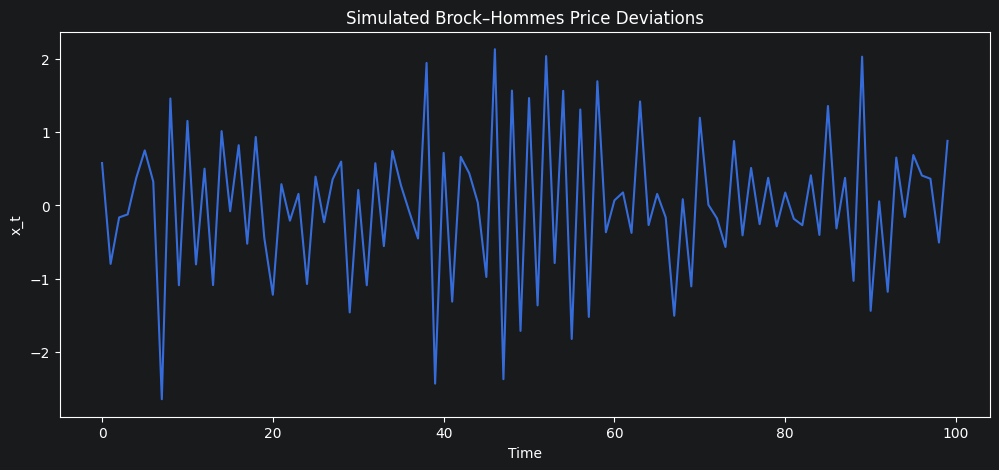

In [4]:
# visualize simulated prices
plt.figure(figsize=(12, 5))

plt.plot(prices_std)

plt.title("Simulated Brock–Hommes Price Deviations")
plt.xlabel("Time")
plt.ylabel("x_t")

plt.show()

## 6. Visualize Evolutionary Strategy Weights

This figure illustrates how trader market shares evolve over time according to adaptive fitness dynamics.

The market shares reflect:
* evolutionary competition,
* adaptive switching,
* and changing profitability of trading strategies.

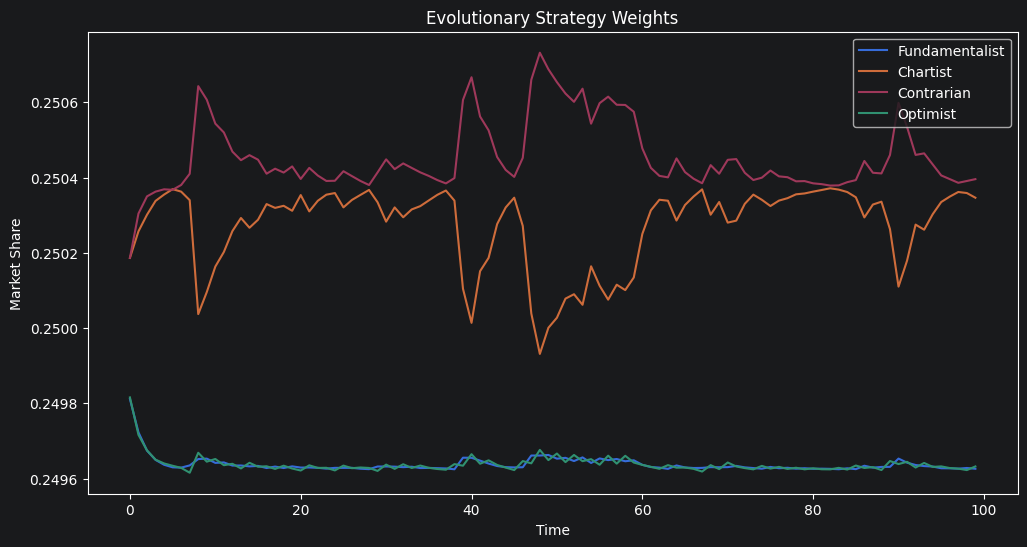

In [5]:
# visualize evolutionary market shares
labels = [
    "Fundamentalist",
    "Chartist",
    "Contrarian",
    "Optimist",
]

plt.figure(figsize=(12, 6))

for i in range(weights_history.shape[1]):

    plt.plot(
        weights_history[:, i],
        label=labels[i]
    )

plt.legend()

plt.title("Evolutionary Strategy Weights")
plt.xlabel("Time")
plt.ylabel("Market Share")

plt.show()

## 7. Bayesian Hierarchical Model Specification
This section constructs the Bayesian hierarchical model.

The model assumes trader forecasting rules:
$$
f_h(x_{t-1}) = g_h x_{t-1} + b_h
$$
where
* $g_h$ represents trend-following behavior,
* $b_h$ represents behavioral bias.

Hierarchical priors allow trader-specific parameters to share common structure while remaining heterogeneous.

The Bayesian model estimates:
* trader trend coefficients,
* trader biases,
* observation uncertainty,
* and latent behavioral heterogeneity.


In [6]:
# bayesian hierarchical model
bh_model = BHHierarchicalModel(observed_prices = prices_std, n_traders=len(traders))
model = bh_model.build()

## 8. MCMC Estimation Using PyMC
Hamiltonian Monte Carlo (HMC) with the No-U-Turn Sampler (NUTS) is used for posterior inference.

The sampling configuration balances:
* computational efficiency,
* posterior exploration,
* and numerical stability.

In [32]:
# run mcmc inference
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        return_inferencedata=True,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [mu_g, sigma_g, mu_b, sigma_b, g, b, obs_sigma]


<div><progress max="4000" value="4000"></progress> 100.00% [4000/4000 06:31&lt;00:00... Sampling 2 chains, 3 divergences]</div>

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 391 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## 9. MCMC Diagnostics

This section evaluates convergence and sampling quality

The diagnostics include:
* R-hat statistics,
* effective sample sizes,
* trace plots,
* and divergence diagnostics.

Good convergence is generally indicated by:
* R-hat values close to 1.0,
* well-mixed chains,
* and absence of divergences.

## 9.1 R-hat Diagnostics

In [33]:
# get rhat plots
az.rhat(trace)

<xarray.Dataset> Size: 168B
Dimensions:    (b_dim_0: 4, g_dim_0: 4)
Coordinates:
  * b_dim_0    (b_dim_0) int64 32B 0 1 2 3
  * g_dim_0    (g_dim_0) int64 32B 0 1 2 3
Data variables:
    mu_g       float64 8B 1.029
    mu_b       float64 8B 1.004
    b          (b_dim_0) float64 32B 1.009 1.012 1.019 1.01
    sigma_g    float64 8B 1.053
    sigma_b    float64 8B 1.03
    g          (g_dim_0) float64 32B 1.032 1.038 1.029 1.03
    obs_sigma  float64 8B 1.0
Attributes:
    created_at:                 2026-05-22T15:12:30.682001+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.10.4
    sampling_time:              391.27205181121826
    tuning_steps:               1000

### 9.2 Posterior Summary Statistics

The posterior summary provides:
* posterior means,
* standard deviations,
* credible intervals,
* effective sample sizes,
* and convergence diagnostics.


In [34]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_g,0.794,0.131,0.585,1.081,0.004,0.007,1275.0,807.0,1.03
mu_b,-0.013,0.045,-0.099,0.071,0.001,0.002,1493.0,1158.0,1.00
b[0],-0.018,0.089,-0.184,0.162,0.003,0.005,1222.0,708.0,1.01
b[1],-0.017,0.087,-0.163,0.161,0.002,0.005,1436.0,895.0,1.01
b[2],-0.015,0.090,-0.175,0.174,0.003,0.005,1303.0,780.0,1.02
b[3],-0.013,0.089,-0.184,0.166,0.003,0.005,1225.0,793.0,1.01
sigma_g,0.163,0.112,0.001,0.353,0.012,0.003,47.0,45.0,1.05
sigma_b,0.076,0.056,0.001,0.177,0.005,0.002,92.0,77.0,1.03
g[0],0.765,0.113,0.583,1.000,0.003,0.005,961.0,528.0,1.03
g[1],0.760,0.117,0.559,0.996,0.004,0.005,824.0,540.0,1.04


### 9.3 Trace Plots

Trace plots are used to assess:
* chain mixing,
* stationarity,
* and posterior exploration.

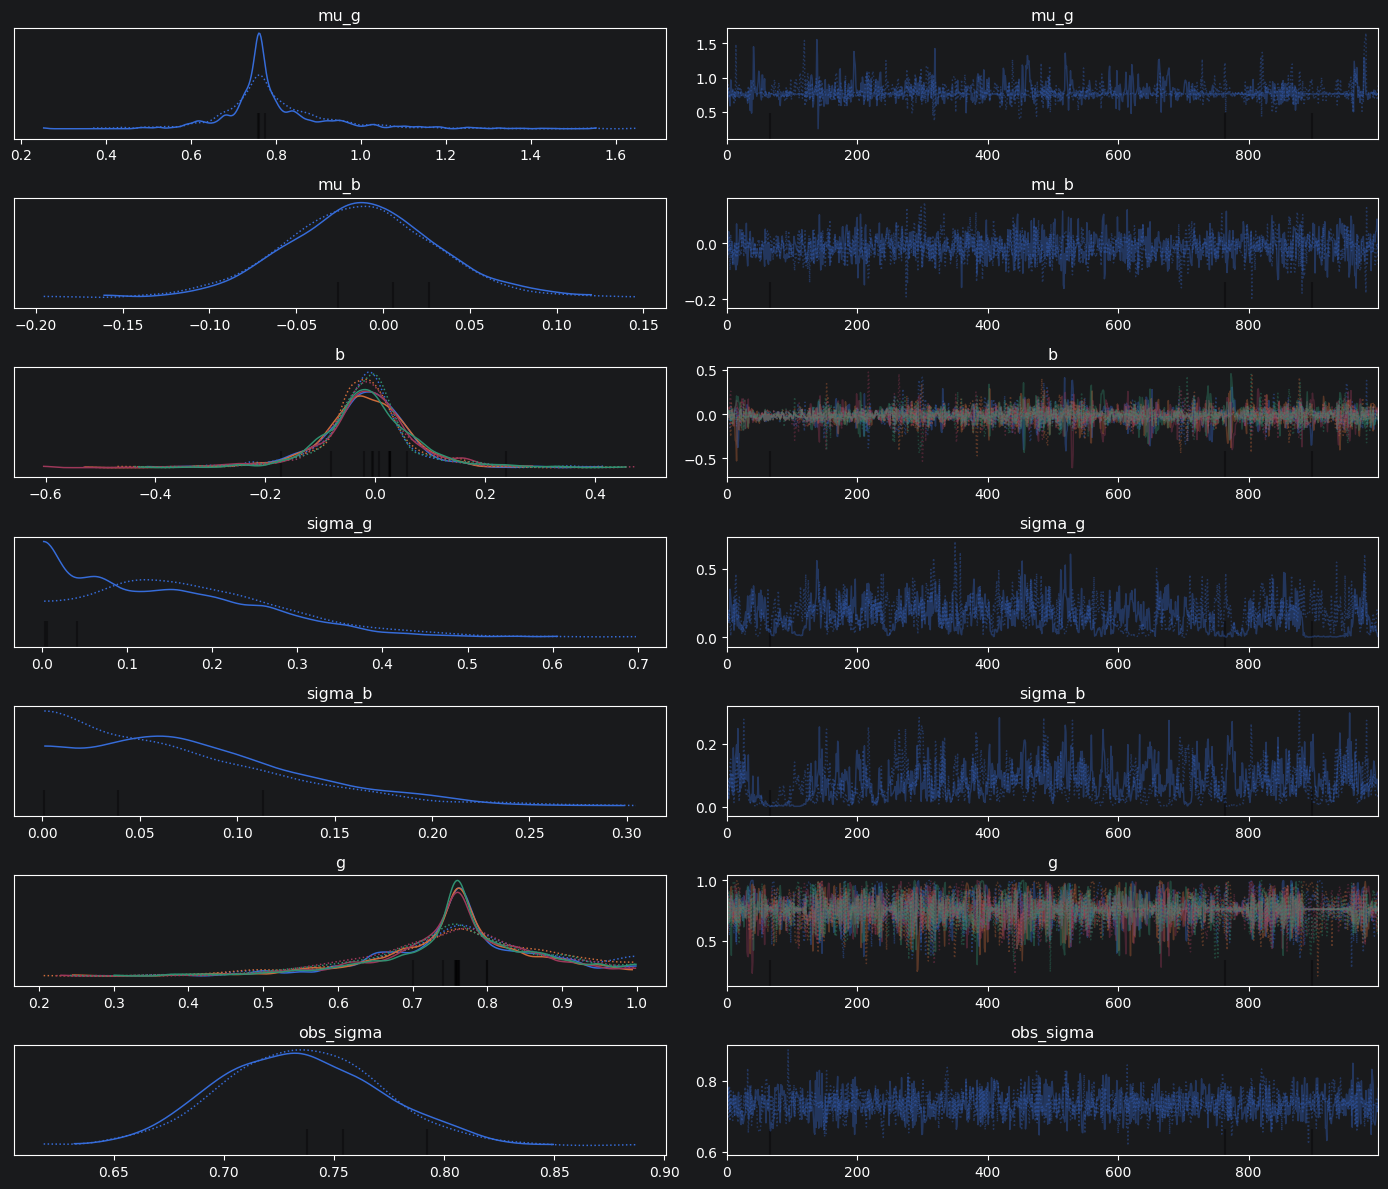

In [35]:
# trace diagnostics
az.plot_trace(
    data=trace,
    figsize=(14, 12),
)

plt.tight_layout()
plt.show()

### Trace Diagnostics Interpretation

The trace diagnostics suggest that the Bayesian hierarchical model achieved reasonably stable posterior sampling behavior. Most Markov chains fluctuate around stable mean values without strong drift, indicating approximate convergence of the sampler.

The posterior distribution of the global trend parameter $\mu_g$ is centered around positive values, implying that the simulated market exhibits moderate trend-following behavior. This result is consistent with the presence of chartist traders in the Brock-Hommes simulation.

The trader-specific trend coefficients $g$ are also concentrated around positive values, although hierarchical shrinkage pulls extreme estimates toward the global mean. This indicates that traders share similar forecasting behavior while still maintaining some heterogeneity.

In contrast, the behavioral bias parameters $b$ are centered close to zero with relatively wide overlap across traders. This suggests that fixed optimistic or pessimistic biases play a limited role in explaining the simulated price dynamics.

The posterior distributions for the hierarchical variance parameters $\sigma_g$ and $\sigma_b$ indicate moderate heterogeneity in trend-following behavior but relatively weak heterogeneity in trader biases.

Finally, the observation noise parameter $\text{obs}_\sigma$ remains relatively large, implying that a substantial portion of market volatility is not fully captured by the simplified Bayesian specification. This reflects the inherent complexity and stochasticity of adaptive heterogeneous agent systems.

### 9.4 Divergence Diagnostics
Divergences indicate problematic posterior geometry.

A low number of divergences suggests numerically stable sampling.

In [36]:
print("Total divergences:", trace.sample_stats["diverging"].sum().values)

Total divergences: 3


## 10. Posterior Analysis
This section analyzes posterior distributions of trader behavioral parameters.

The posterior distributions provide insight into:
* trend-following intensity,
* mean-reversion behavior,
* behavioral bias,
* and uncertainty in trader beliefs.

### 10.1 Posterior Distributions

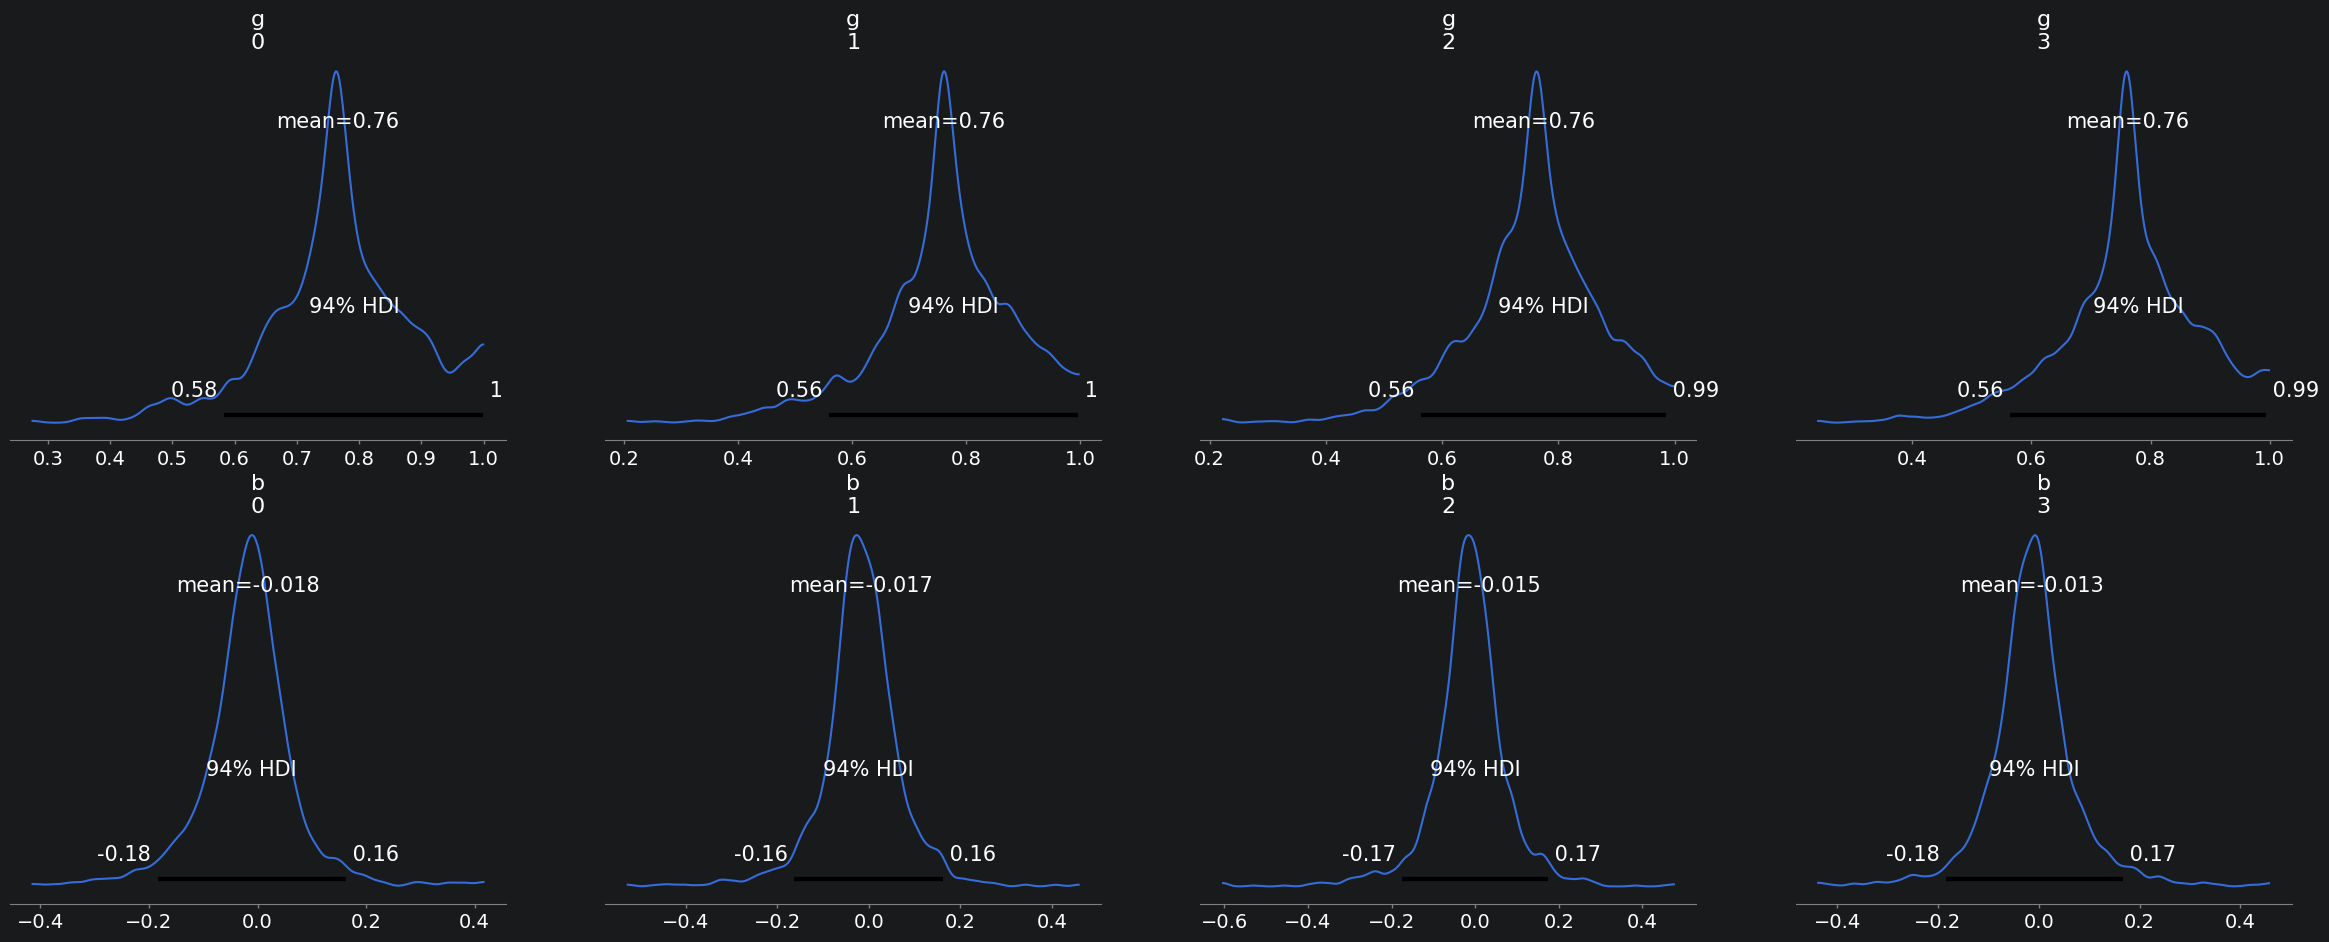

In [37]:
# posterior distributions of trader parameters
az.plot_posterior(data=trace, var_names=["g","b"])
plt.show()

The figure shows the posterior distributions of the trader-specific parameters $g_h$ and $b_h$ estimated from the Bayesian hierarchical Brock--Hommes model.

The top row displays the posterior distributions of the trend-following coefficients $g_h$ for the four trader types. All posterior distributions are centered around approximately $0.75$, with 94\% highest density intervals (HDI) roughly between $0.55$ and $1.0$. This indicates that the model infers moderate positive trend-following behavior across all traders. In economic terms, traders tend to extrapolate recent price movements rather than strongly reverting toward fundamentals.

The posterior distributions of $g_h$ are also highly concentrated and similar across trader types. This reflects the effect of hierarchical shrinkage, where trader-specific estimates are partially pooled toward the global mean parameter $\mu_g$. As a result, the Bayesian hierarchical model regularizes extreme parameter values and improves numerical stability.

The bottom row shows the posterior distributions of the behavioral bias parameters $b_h$. These distributions are centered close to zero, with posterior means ranging approximately between $-0.02$ and $0.01$. The corresponding HDI intervals contain both positive and negative values, suggesting substantial uncertainty regarding persistent trader optimism or pessimism.

Overall, the posterior analysis suggests that trend-following dynamics play a more important role than fixed behavioral biases in explaining the simulated market behavior. The relatively narrow posterior distributions also indicate that the Bayesian model estimates the trader parameters with reasonable precision under the imposed regularization constraints.

### 10.2 Forest Plot
Forest plots summarize posterior uncertainty and credible intervals for trader parameters.

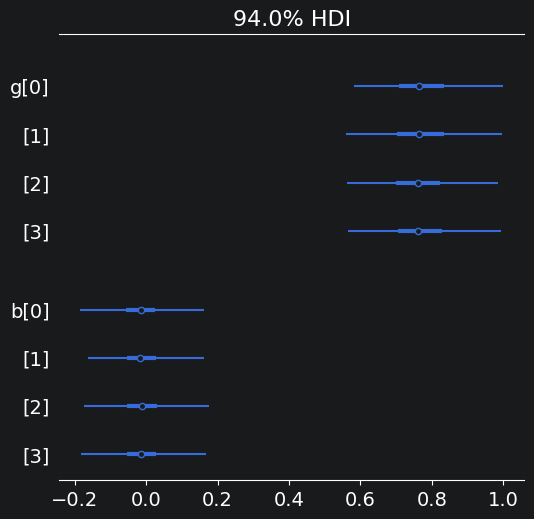

In [38]:
az.plot_forest(
    trace,
    var_names=["g","b"],
    combined=True,
)

plt.show()

## 11. Posterior Predictive Checks

Posterior predictive checks evaluate how well the Bayesian model reproduces the observed simulated market dynamics.

The posterior predictive distribution generates synthetic observations conditional on posterior parameter draws:

In [39]:
# posterior predictive checks
with model:
    ppc = pm.sample_posterior_predictive(trace=trace)

Sampling: [x_obs]


<div><progress max="2000" value="2000"></progress> 100.00% [2000/2000 00:00&lt;00:00]</div>

### 11.1 Compare Observed vs Fitted Prices
This figure compares:
* observed simulated prices,
* and posterior predictive means.

A good fit should capture:
* overall volatility,
* persistence,
* and directional movements.

In [ ]:
posterior_mean = (
    ppc.posterior_predictive["x_obs"].mean(dim=["chain","draw"]).values
)

plt.figure(figsize=(12, 5))

plt.plot(prices_std, label="Observed")
plt.plot(posterior_mean, label="Posterior Mean")

plt.legend()

plt.title("Observed vs Bayesian Posterior Mean")

plt.show()

## Posterior Predictive Check Interpretation
The posterior predictive check compares the observed simulated price deviations with the Bayesian posterior predictive mean. The posterior predictions successfully capture the general oscillatory and mean-reverting structure of the simulated market dynamics. However, the posterior mean is substantially smoother and exhibits lower volatility than the observed series.

This indicates that the Bayesian hierarchical model captures the average behavioral structure of the market but underestimates extreme fluctuations and volatility spikes generated by the full Brock-Hommes simulation. The discrepancy arises because the simplified Bayesian specification regularized trader behavior through hierarchical priors and truncation constraints, reducing explosive dynamics and improving numerical stability.

The results suggest that while the Bayesian model provides stable probabilistic inference, substantial nonlinear market dynamics remain unexplained. This reflects the inherent complexity of adaptive heterogeneous agent systems and highlights the trade-off between model stability and flexibility.

### 11.2 Posterior Predictive Density Check

Posterior predictive density checks compare the observed distribution again simulated posterior predictive distributions.

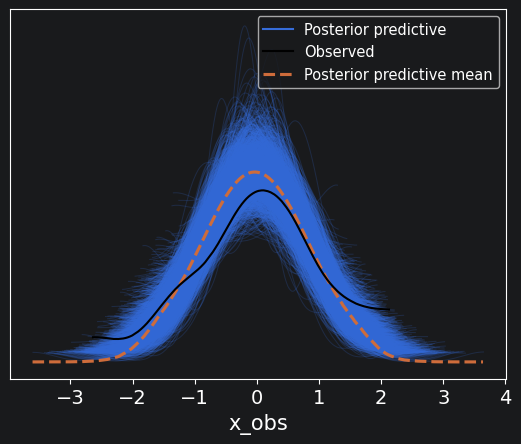

In [41]:
az.plot_ppc(ppc)
plt.show()

### Posterior Predictive Check Interpretation

The posterior predictive check evaluates how well the Bayesian hierarchical Brock--Hommes model reproduces the observed price dynamics.

In the figure:

- The **black curve** represents the distribution of the observed standardized prices.
- The **blue curves** represent simulated datasets generated from the posterior distribution.
- The **orange dashed curve** shows the mean posterior predictive distribution.

### Key Findings

The posterior predictive distributions broadly overlap with the observed distribution, indicating that the model captures the general shape and central tendency of the simulated market prices reasonably well.

The observed data exhibit a bell-shaped distribution centered near zero, and the posterior predictive mean closely follows this structure. This suggests that the hierarchical model successfully captures the average level and overall volatility of the market dynamics.

However, some differences remain between the observed and predictive distributions:

- The posterior predictive distribution appears slightly smoother and more symmetric than the observed data.
- Extreme observations in the tails are not fully reproduced by the model.
- The predictive simulations underestimate some sharp fluctuations present in the observed series.

These results imply that the simplified hierarchical specification captures the broad statistical behavior of the Brock--Hommes system but does not fully reproduce the nonlinear volatility and abrupt market movements generated by heterogeneous adaptive trading behavior.

Overall, the posterior predictive check suggests that the Bayesian hierarchical model provides a stable and reasonable approximation of the underlying market dynamics while remaining computationally tractable.


## 12. Interpretation of Results
The Bayesian hierarchical model successfully captures the general behavioral structure of the simulated Brock–Hommes market. Posterior distributions indicate moderate trend-following behavior, while trader bias parameters remain close to zero, suggesting that momentum effects are more important than persistent optimism or pessimism.

Trace diagnostics show relatively stable and well-mixed Markov chains, indicating approximate convergence of the sampler. Hierarchical priors help regularize trader parameters and improve numerical stability.

Posterior predictive checks show that the model captures the overall oscillatory behavior of the observed price dynamics. However, the fitted posterior mean is smoother and less volatile than the observed series, indicating that the simplified Bayesian specification underestimates extreme market fluctuations and nonlinear feedback effects.

Overall, the results highlight the trade-off between numerical stability and model flexibility in Bayesian estimation of adaptive heterogeneous agent systems.
